In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import TransformedTargetRegressor, ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from essential_functions import scatter_comparison_train_test_plot, feature_importance_plot  
import warnings
warnings.filterwarnings('ignore')

/Users/danmayonde/Desktop/ML_Master_Project/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# The output directory of all the files saved in this notebook
output_path = os.path.join('..', 'feature_importance')

In [3]:
# Load Data

df = ((pd.read_csv("../Data/BData.csv")).drop(columns=["Sample_ID"])).dropna()

# Transform Aspect to Sine and Cosine
aspect_rad = np.radians(df["Aspect (˚)"])   # Convert to radians

# Insert the two new features next to "Aspect (˚)"
df.insert(5, "aspect_sin", np.sin(aspect_rad))
df.insert(6, "aspect_cos", np.cos(aspect_rad))

# Drop "Aspect (˚)" from the data frame
df.drop(["Aspect (˚)"], axis=1, inplace=True)

# Encode the Categorical Feature "Land Use" to 1 for "residential" and 0 for "barren"
df["Land Use"] = (df["Land Use"] == "residential").astype(int)

df.head()

,Longitude,Latitude,Slope (%),Elevation (m),aspect_sin,aspect_cos,NDVI,Land Use,Dist_Main_Road (m),Dist_Near_Road (m),...,Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,16.654245,-23.791474,4.54993,1554,-0.371390,0.928477,0.0655,0,2473,1535,...,91.2,7.6,1.2,7.3,100.0,50.0,1.56,247.980,30.210,9.123
1,16.654298,-23.791963,4.22451,1557,0.800000,-0.600000,0.0684,0,2507,1533,...,87.9,10.4,1.6,7.9,137.0,68.0,1.65,359.081,31.586,8.282
2,16.654220,-23.792418,6.00415,1555,0.633238,-0.773957,0.0672,0,2529,1521,...,91.8,7.0,1.3,7.1,109.0,54.5,2.62,243.819,31.527,5.749
3,16.654164,-23.792956,6.09267,1551,0.832050,-0.554700,0.0590,0,2559,1511,...,89.7,8.8,1.5,7.5,90.0,44.5,2.25,314.907,34.707,9.071
4,16.653748,-23.792745,3.04634,1554,0.554700,-0.832050,0.0593,0,2511,1470,...,86.4,12.0,1.6,8.0,119.0,59.5,2.12,384.931,26.657,8.338


## Log Transformation

In [4]:
# Log10 Transformation
print('/.. run log transformation...')
# Variables to transform
feat_transform = ["Clay (%)", "TDS (mg/L)", "SOM (g/kg)", 'NDVI']

# log10 transformation of variables
for feature in feat_transform:
    df[feature] = np.log10(df[feature])

print('feature transformation complete...')

/.. run log transformation...
feature transformation complete...


In [5]:
df.head()

,Longitude,Latitude,Slope (%),Elevation (m),aspect_sin,aspect_cos,NDVI,Land Use,Dist_Main_Road (m),Dist_Near_Road (m),...,Sand (%),Silt (%),Clay (%),pH,EC (µs/cm),TDS (mg/L),SOM (g/kg),Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,16.654245,-23.791474,4.54993,1554,-0.371390,0.928477,-1.183759,0,2473,1535,...,91.2,7.6,0.079181,7.3,100.0,1.698970,0.193125,247.980,30.210,9.123
1,16.654298,-23.791963,4.22451,1557,0.800000,-0.600000,-1.164944,0,2507,1533,...,87.9,10.4,0.204120,7.9,137.0,1.832509,0.217484,359.081,31.586,8.282
2,16.654220,-23.792418,6.00415,1555,0.633238,-0.773957,-1.172631,0,2529,1521,...,91.8,7.0,0.113943,7.1,109.0,1.736397,0.418301,243.819,31.527,5.749
3,16.654164,-23.792956,6.09267,1551,0.832050,-0.554700,-1.229148,0,2559,1511,...,89.7,8.8,0.176091,7.5,90.0,1.648360,0.352183,314.907,34.707,9.071
4,16.653748,-23.792745,3.04634,1554,0.554700,-0.832050,-1.226945,0,2511,1470,...,86.4,12.0,0.204120,8.0,119.0,1.774517,0.326336,384.931,26.657,8.338


In [6]:
targets = ['Cu (mg/kg)', 'Zn (mg/kg)', 'Pb (mg/kg)']
redundant_features = ["Longitude", "Latitude", "Dist_Main_Road  (m)", "EC (µs/cm)", "Sand (%)"]

features_to_drop = targets + redundant_features

# Create X Data and y

X = df.drop(columns=features_to_drop).copy()

y = df[targets].copy()

feature_cols = X.columns

y.head()

,Cu (mg/kg),Zn (mg/kg),Pb (mg/kg)
0,247.980,30.210,9.123
1,359.081,31.586,8.282
2,243.819,31.527,5.749
3,314.907,34.707,9.071
4,384.931,26.657,8.338


In [7]:
numeric_features = ['Slope (%)', 'Elevation (m)', 'aspect_sin', 'aspect_cos', 'NDVI', 'Dist_Near_Road (m)', 'Dist_Tailing (m)', 'Silt (%)',
       'Clay (%)', 'pH', 'TDS (mg/L)', 'SOM (g/kg)']
categorical_features = ['Land Use']

In [8]:
# Preprocesser Scaler that leaves the categorical features unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)  # leave as-is
    ]
)

# scoring metrics to be used for cross validation
scoring = {'r2': 'r2',
          'mae': 'neg_mean_absolute_error',
          'rmse': 'neg_root_mean_squared_error'
          }

## Split The Dataset Into Training an Test Set

In [9]:
# Split the DataSet into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sperating targets array into different arrays
y_train_Cu = y_train[targets[0]]
y_train_Zn = y_train[targets[1]]
y_train_Pb = y_train[targets[2]]

y_test_Cu = y_test[targets[0]]
y_test_Zn = y_test[targets[1]]
y_test_Pb = y_test[targets[2]]

# PREDICTION OF Cu CONCENTRATIONS

In [10]:
# Load the Model
mlp_model_Cu = MLPRegressor(activation="tanh",
                            alpha= 0.6,
                            hidden_layer_sizes=(50, 50),
                            learning_rate_init=0.06,
                            max_iter=50,
                            solver="adam",
                           random_state=42)
# Define the pipeline
mlp_pipeline_Cu = Pipeline([
    ('scaler', preprocessor),
    ('mlp', mlp_model_Cu)
])

mlp_Cu = TransformedTargetRegressor(
    regressor=mlp_pipeline_Cu,
    func=np.log10,
    inverse_func=lambda x: 10**x
)

# Fit the model
mlp_Cu.fit(X_train, y_train_Cu)

# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        mlp_Cu, X_train, y_train_Cu, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)
    
# Predicting on the training set
y_train_pred_Cu = mlp_Cu.predict(X_train)

r2_train = r2_score(y_train_Cu, y_train_pred_Cu)
mae_train = mean_absolute_error(y_train_Cu, y_train_pred_Cu)
rmse_train = np.sqrt(mean_squared_error(y_train_Cu, y_train_pred_Cu))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.1639
MAE: 50.5885
RMSE: 78.4994

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.2858
MAE: 40.8906
RMSE: 80.3710


In [11]:
# Predict on the test set
y_pred_Cu = mlp_Cu.predict(X_test)

r2 = r2_score(y_test_Cu, y_pred_Cu)
mae = mean_absolute_error(y_test_Cu, y_pred_Cu)
rmse = np.sqrt(mean_squared_error(y_test_Cu, y_pred_Cu))

# Predicting on the training set
y_train_pred_Cu = mlp_Cu.predict(X_train)

r2_train = r2_score(y_train_Cu, y_train_pred_Cu)
mae_train = mean_absolute_error(y_train_Cu, y_train_pred_Cu)
rmse_train = np.sqrt(mean_squared_error(y_train_Cu, y_train_pred_Cu))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.2028
MAE: 54.5092
RMSE: 74.9604

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.2858
MAE: 40.8906
RMSE: 80.3710


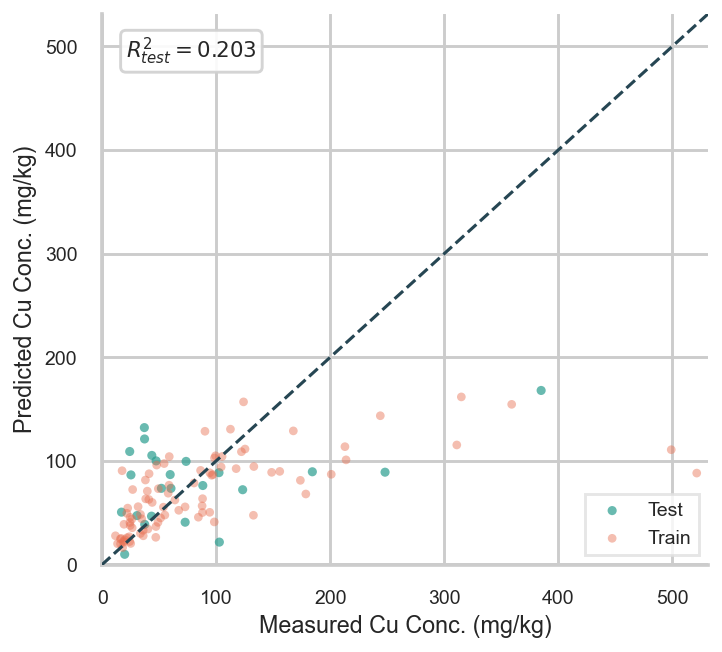

In [12]:
scatter_comparison_train_test_plot(y_pred_Cu,
                                  y_test_Cu,
                                  y_train_pred_Cu,
                                  y_train_Cu,
                                  x_label='Measured Cu Conc. (mg/kg)',
                                  y_label='Predicted Cu Conc. (mg/kg)',
                                  file_name='Cu_pred_vs_true_MLP.png')

In [13]:
# Wrap full pipeline predict (returns predictions in original Cu space)
def predict_fn(X):
    return mlp_Cu.predict(pd.DataFrame(X, columns=X_train.columns))
    
np.random.seed(42)
explainer_Cu   = shap.KernelExplainer(predict_fn, X_train)
shap_values_Cu = explainer_Cu.shap_values(X_test)

# Feature names
feature_names = X_test.columns.tolist()

shap_results_Cu = {}

# Store results
shap_results_Cu[targets[0]] = {
    'explainer': explainer_Cu,
    'shap_values': shap_values_Cu,
    'model': mlp_Cu
}

# Calculate mean absolute SHAP values for feature importance
shap_importance_Cu = pd.DataFrame({
    'Feature': feature_names,
    'Mean_|SHAP|': np.abs(shap_values_Cu).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)

# Add percentage contribution column
shap_importance_Cu["Contribution (%)"] = (
    shap_importance_Cu["Mean_|SHAP|"] / shap_importance_Cu["Mean_|SHAP|"].sum() * 100
).round(2)

shap_importance_Cu['Cumulative (%)'] = shap_importance_Cu["Contribution (%)"].cumsum()

safe_name = targets[0].replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
importance_Cu_path = os.path.join(output_path, safe_name)
print(f"\n  Important Features for {targets[0]} (by Mean |SHAP|):")
print(shap_importance_Cu.to_string(index=False))

shap_importance_Cu.to_csv(f'{importance_Cu_path}_MLP.csv', index=False)

100%|██████████████████████████████████████████████████████████████████████████| 23/23 [00:06<00:00,  3.79it/s]


  Important Features for Cu (mg/kg) (by Mean |SHAP|):
           Feature  Mean_|SHAP|  Contribution (%)  Cumulative (%)
  Dist_Tailing (m)    15.686720             16.84           16.84
          Silt (%)    11.726239             12.59           29.43
     Elevation (m)    11.444349             12.28           41.71
          Clay (%)     9.168038              9.84           51.55
        aspect_sin     8.306631              8.92           60.47
              NDVI     6.977428              7.49           67.96
          Land Use     6.947191              7.46           75.42
        SOM (g/kg)     5.304674              5.69           81.11
        TDS (mg/L)     5.158363              5.54           86.65
                pH     4.359319              4.68           91.33
         Slope (%)     3.889557              4.17           95.50
        aspect_cos     3.811152              4.09           99.59
Dist_Near_Road (m)     0.386413              0.41          100.00


# PREDICTION of Zn CONCENTRATIONS

In [14]:
# Load the MLP Model
mlp_model_Zn = MLPRegressor(activation="relu",
                            alpha= 1.,
                            hidden_layer_sizes=(32, 32, 16),
                            learning_rate_init=0.05,
                            max_iter=200,
                            solver="adam",
                           random_state=42)
# Define the pipeline
mlp_pipeline_Zn = Pipeline([
    ('scaler', preprocessor),
    ('mlp', mlp_model_Zn)
])
 
mlp_Zn = TransformedTargetRegressor(
    regressor=mlp_pipeline_Zn,
    func=np.log10,
    inverse_func=lambda x: 10**x
)

# Fit the model
mlp_Zn.fit(X_train, y_train_Zn)

# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        mlp_Zn, X_train, y_train_Zn, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)
    
# Predicting on the training set
y_train_pred_Zn = mlp_Zn.predict(X_train)

r2_train = r2_score(y_train_Zn, y_train_pred_Zn)
mae_train = mean_absolute_error(y_train_Zn, y_train_pred_Zn)
rmse_train = np.sqrt(mean_squared_error(y_train_Zn, y_train_pred_Zn))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.0907
MAE: 9.5563
RMSE: 15.2171

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.1459
MAE: 8.7670
RMSE: 16.2712


In [15]:
# Predict on the test set
y_pred_Zn = mlp_Zn.predict(X_test)

r2 = r2_score(y_test_Zn, y_pred_Zn)
mae = mean_absolute_error(y_test_Zn, y_pred_Zn)
rmse = np.sqrt(mean_squared_error(y_test_Zn, y_pred_Zn))

# Predicting on the training set
y_train_pred_Zn = mlp_Zn.predict(X_train)

r2_train = r2_score(y_train_Zn, y_train_pred_Zn)
mae_train = mean_absolute_error(y_train_Zn, y_train_pred_Zn)
rmse_train = np.sqrt(mean_squared_error(y_train_Zn, y_train_pred_Zn))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.0620
MAE: 7.4828
RMSE: 11.0077

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.1459
MAE: 8.7670
RMSE: 16.2712


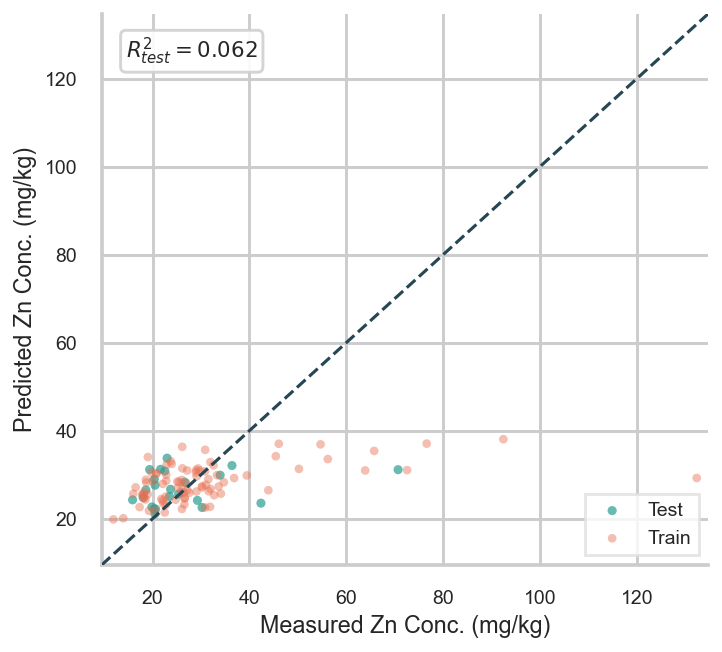

In [16]:
scatter_comparison_train_test_plot(y_pred_Zn,
                                  y_test_Zn,
                                  y_train_pred_Zn,
                                  y_train_Zn,
                                  x_label='Measured Zn Conc. (mg/kg)',
                                  y_label='Predicted Zn Conc. (mg/kg)',
                                  file_name='Zn_pred_vs_true_MLP.png')

In [17]:
# Wrap full pipeline predict (returns predictions in original Zn space)
def predict_fn(X):
    return mlp_Zn.predict(pd.DataFrame(X, columns=X_train.columns))
    
np.random.seed(42)
explainer_Zn   = shap.KernelExplainer(predict_fn, X_train)
shap_values_Zn = explainer_Zn.shap_values(X_test)

# Feature names
feature_names = X_test.columns.tolist()

shap_results_Zn = {}

# Store results
shap_results_Zn[targets[1]] = {
    'explainer': explainer_Zn,
    'shap_values': shap_values_Zn,
    'model': mlp_Zn
}

# Calculate mean absolute SHAP values for feature importance
shap_importance_Zn = pd.DataFrame({
    'Feature': feature_names,
    'Mean_|SHAP|': np.abs(shap_values_Zn).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)

# Add percentage contribution column
shap_importance_Zn["Contribution (%)"] = (
    shap_importance_Zn["Mean_|SHAP|"] / shap_importance_Zn["Mean_|SHAP|"].sum() * 100
).round(2)

shap_importance_Zn['Cumulative (%)'] = shap_importance_Zn["Contribution (%)"].cumsum()

safe_name = targets[1].replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
importance_Zn_path = os.path.join(output_path, safe_name)
print(f"\n  Important Features for {targets[1]} (by Mean |SHAP|):")
print(shap_importance_Zn.to_string(index=False))

shap_importance_Zn.to_csv(f'{importance_Zn_path}_MLP.csv', index=False)

100%|██████████████████████████████████████████████████████████████████████████| 23/23 [00:03<00:00,  7.01it/s]


  Important Features for Zn (mg/kg) (by Mean |SHAP|):
           Feature  Mean_|SHAP|  Contribution (%)  Cumulative (%)
        SOM (g/kg)     2.355668             32.22           32.22
        aspect_sin     0.930115             12.72           44.94
          Clay (%)     0.782349             10.70           55.64
        aspect_cos     0.728366              9.96           65.60
  Dist_Tailing (m)     0.671815              9.19           74.79
          Silt (%)     0.645225              8.83           83.62
Dist_Near_Road (m)     0.399288              5.46           89.08
          Land Use     0.306741              4.20           93.28
         Slope (%)     0.189730              2.60           95.88
              NDVI     0.093855              1.28           97.16
        TDS (mg/L)     0.093529              1.28           98.44
     Elevation (m)     0.073629              1.01           99.45
                pH     0.040800              0.56          100.01


# PREDICTION OF Pb CONCENTRATIONS

In [18]:
#Load the Model
mlp_model_Pb = MLPRegressor(activation="relu",
                            alpha=2.,
                            hidden_layer_sizes=(32,),
                            learning_rate_init=0.06,
                            max_iter=35,
                            solver="sgd",
                           random_state=42)
# Define the pipeline
mlp_pipeline_Pb = Pipeline([
    ('scaler', preprocessor),
    ('svr', mlp_model_Pb)
])
# Load 
mlp_Pb = TransformedTargetRegressor(
    regressor=mlp_pipeline_Pb,
    func=np.log10,
    inverse_func=lambda x: 10**x
)

# Fit the model
mlp_Pb.fit(X_train, y_train_Pb)

# Cross Validation 5 k-folds
scores = []

for metric in scoring:
    score = cross_val_score(
        mlp_Pb, X_train, y_train_Pb, cv=5, scoring=scoring[metric]
    ).mean()
    scores.append(score)
    
# Predicting on the training set
y_train_pred_Pb = mlp_Pb.predict(X_train)

r2_train = r2_score(y_train_Pb, y_train_pred_Pb)
mae_train = mean_absolute_error(y_train_Pb, y_train_pred_Pb)
rmse_train = np.sqrt(mean_squared_error(y_train_Pb, y_train_pred_Pb))

print('#' * 40)
print('-' *10,'Validation Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {scores[0]:.4f}')
print(f'MAE: {-scores[1]:.4f}')
print(f'RMSE: {-scores[2]:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Validation Set Scores ----------
########################################
R² Score: 0.0408
MAE: 4.7823
RMSE: 8.3357

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.4216
MAE: 3.4040
RMSE: 7.2535


In [19]:
# Predict on the test set
y_pred_Pb = mlp_Pb.predict(X_test)

r2 = r2_score(y_test_Pb, y_pred_Pb)
mae = mean_absolute_error(y_test_Pb, y_pred_Pb)
rmse = np.sqrt(mean_squared_error(y_test_Pb, y_pred_Pb))

# Predicting on the training set
y_train_pred_Pb = mlp_Pb.predict(X_train)

r2_train = r2_score(y_train_Pb, y_train_pred_Pb)
mae_train = mean_absolute_error(y_train_Pb, y_train_pred_Pb)
rmse_train = np.sqrt(mean_squared_error(y_train_Pb, y_train_pred_Pb))

print('#' * 40)
print('-' *10,'Test Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print('')
print('#' * 40)
print('-' *10,'Training Set Scores', '-' *10)
print('#' * 40)
print(f'R² Score: {r2_train:.4f}')
print(f'MAE: {mae_train:.4f}')
print(f'RMSE: {rmse_train:.4f}')

########################################
---------- Test Set Scores ----------
########################################
R² Score: 0.3959
MAE: 3.7512
RMSE: 8.4187

########################################
---------- Training Set Scores ----------
########################################
R² Score: 0.4216
MAE: 3.4040
RMSE: 7.2535


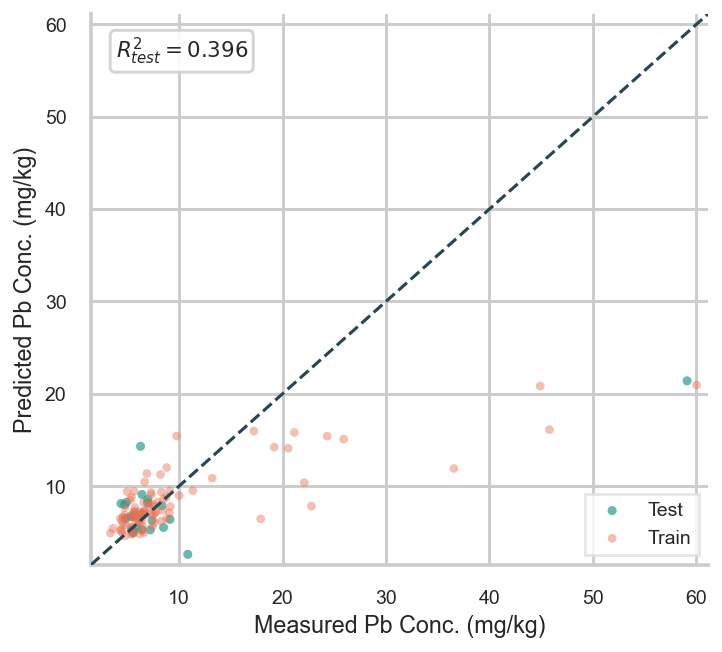

In [20]:
scatter_comparison_train_test_plot(y_pred_Pb,
                                  y_test_Pb,
                                  y_train_pred_Pb,
                                  y_train_Pb,
                                  x_label='Measured Pb Conc. (mg/kg)',
                                  y_label='Predicted Pb Conc. (mg/kg)',
                                  file_name='Pb_pred_vs_true_MLP.png')

In [21]:
# Wrap full pipeline predict (returns predictions in original Pb space)
def predict_fn(X):
    return mlp_Pb.predict(pd.DataFrame(X, columns=X_train.columns))
    
np.random.seed(42)
explainer_Pb   = shap.KernelExplainer(predict_fn, X_train)
shap_values_Pb = explainer_Pb.shap_values(X_test)

# Feature names
feature_names = X_test.columns.tolist()

shap_results_Pb = {}

# Store results
shap_results_Pb[targets[2]] = {
    'explainer': explainer_Pb,
    'shap_values': shap_values_Pb,
    'model': mlp_Pb
}

# Calculate mean absolute SHAP values for feature importance
shap_importance_Pb = pd.DataFrame({
    'Feature': feature_names,
    'Mean_|SHAP|': np.abs(shap_values_Pb).mean(axis=0)
}).sort_values('Mean_|SHAP|', ascending=False)

# Add percentage contribution column
shap_importance_Pb["Contribution (%)"] = (
    shap_importance_Pb["Mean_|SHAP|"] / shap_importance_Pb["Mean_|SHAP|"].sum() * 100
).round(2)

shap_importance_Pb['Cumulative (%)'] = shap_importance_Pb["Contribution (%)"].cumsum()

safe_name = targets[2].replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
importance_Pb_path = os.path.join(output_path, safe_name)
print(f"\n  Important Features for {targets[2]} (by Mean |SHAP|):")
print(shap_importance_Pb.to_string(index=False))

shap_importance_Pb.to_csv(f'{importance_Pb_path}_MLP.csv', index=False)

100%|██████████████████████████████████████████████████████████████████████████| 23/23 [00:02<00:00, 10.28it/s]


  Important Features for Pb (mg/kg) (by Mean |SHAP|):
           Feature  Mean_|SHAP|  Contribution (%)  Cumulative (%)
Dist_Near_Road (m)     1.548085             23.58           23.58
        SOM (g/kg)     1.001978             15.26           38.84
         Slope (%)     0.827922             12.61           51.45
        aspect_cos     0.523560              7.97           59.42
          Clay (%)     0.465947              7.10           66.52
          Land Use     0.464679              7.08           73.60
              NDVI     0.375836              5.72           79.32
                pH     0.350247              5.33           84.65
  Dist_Tailing (m)     0.295094              4.49           89.14
     Elevation (m)     0.226504              3.45           92.59
        aspect_sin     0.186544              2.84           95.43
          Silt (%)     0.164810              2.51           97.94
        TDS (mg/L)     0.134581              2.05           99.99


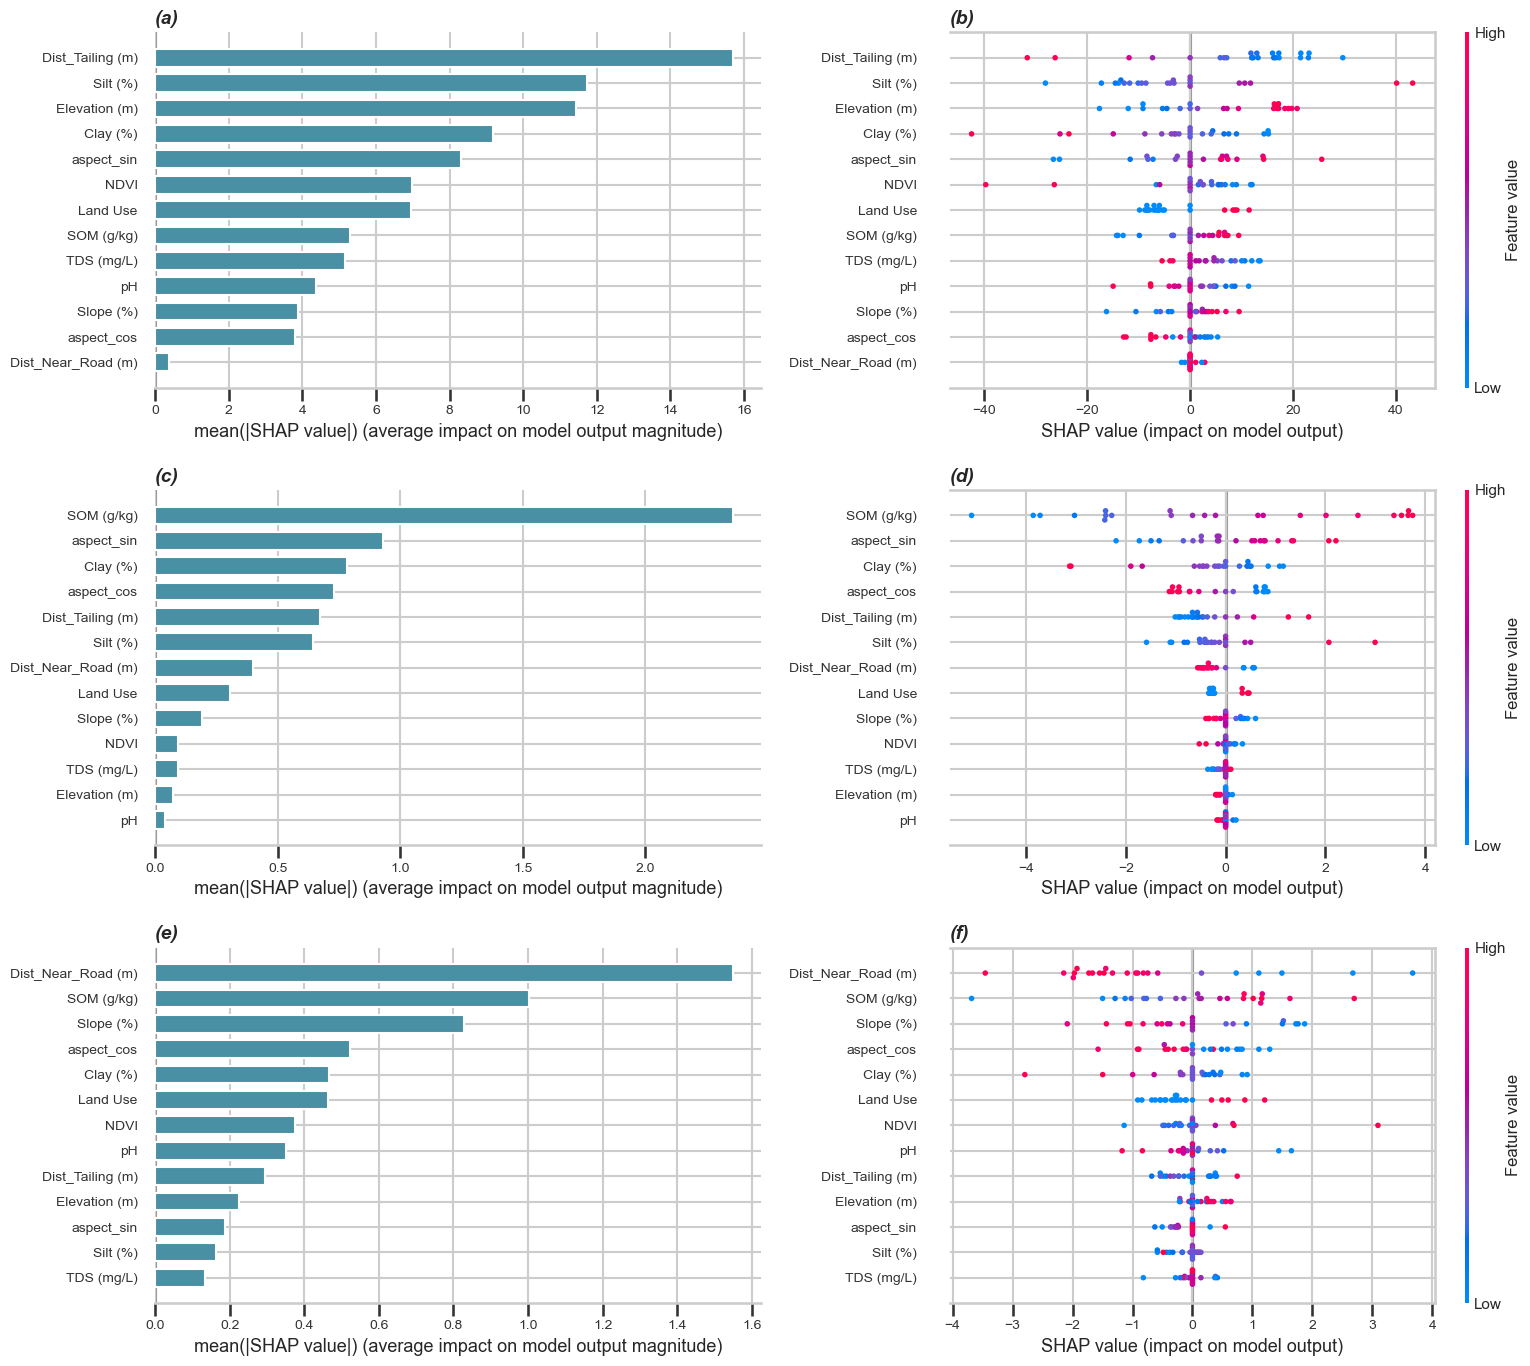

In [22]:
feature_importance_plot(X_test,
                        shap_values_Cu,
                        shap_values_Zn,
                        shap_values_Pb,
                        plot_name="Shap_Feature_Importance_Summary_Cu_Zn_Pb_MLP.png")